# Experiment 2 — Baseline CNN & Transformer Benchmark

Uses the fixed QC-controlled split from Experiment 1. No new random split is created.

**Split:** Train 10,063 | Validation 2,173 | Test 2,160 | Seed 42

**Models:** ResNet50, DenseNet121, EfficientNet-B0, ConvNeXt-Tiny, ViT-B/16, Swin-Tiny

**Metrics:** Accuracy, Balanced Accuracy, F1, ROC-AUC, MCC, Confusion Matrix, ROC Curve.

**Tasks:** L1, L2, L3A Tumor, L3B Alzheimer, L3C Stroke. Parkinson terminates at L2.


In [1]:
!pip -q install torchmetrics

import os, gc, json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve, auc
)

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__)


PyTorch: 2.10.0+cu128


In [2]:
# Reproducibility + configuration
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 1
PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

OUTPUT_ROOT = Path("/kaggle/working/Experiment_2")
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
RESULT_DIR = OUTPUT_ROOT / "results"
PLOT_DIR = OUTPUT_ROOT / "plots"

for p in [OUTPUT_ROOT, CHECKPOINT_DIR, RESULT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [3]:
# Find Experiment 1 CSV files
INPUT_ROOT = Path("/kaggle/input")

def find_csv(name):
    matches = list(INPUT_ROOT.rglob(name))
    if not matches:
        return None
    preferred = [
        p for p in matches
        if any(k in str(p).lower() for k in ["cns", "qc", "split", "publication"])
    ]
    return preferred[0] if preferred else matches[0]

TRAIN_CSV = find_csv("train.csv")
VAL_CSV = find_csv("val.csv")
TEST_CSV = find_csv("test.csv")

print("Train:", TRAIN_CSV)
print("Val  :", VAL_CSV)
print("Test :", TEST_CSV)

assert TRAIN_CSV is not None, "train.csv not found."
assert VAL_CSV is not None, "val.csv not found."
assert TEST_CSV is not None, "test.csv not found."

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

assert len(train_df) == 10063
assert len(val_df) == 2173
assert len(test_df) == 2160

print("✓ Experiment 1 split verified.")


Train: /kaggle/input/datasets/sabbir132h/cns-qc-output/CNS_QC_OUTPUT/train.csv
Val  : /kaggle/input/datasets/sabbir132h/cns-qc-output/CNS_QC_OUTPUT/val.csv
Test : /kaggle/input/datasets/sabbir132h/cns-qc-output/CNS_QC_OUTPUT/test.csv
Train: 10063
Val  : 2173
Test : 2160
✓ Experiment 1 split verified.


In [4]:
# Find original CNS dataset
CANDIDATES = [
    Path("/kaggle/input/datasets/sabbir132h/cns-dataset/CNS"),
    Path("/kaggle/input/cns-dataset/CNS"),
    Path("/kaggle/input/CNS")
]

CNS_ROOT = next((p for p in CANDIDATES if p.exists()), None)

if CNS_ROOT is None:
    matches = [p for p in INPUT_ROOT.rglob("CNS") if p.is_dir()]
    CNS_ROOT = matches[0] if matches else None

assert CNS_ROOT is not None, "Original CNS dataset root not found."

print("CNS_ROOT:", CNS_ROOT)
print(train_df.columns.tolist())


CNS_ROOT: /kaggle/input/datasets/sabbir132h/cns-dataset/CNS
['relative_path', 'absolute_path', 'filename', 'stem', 'extension', 'parent_folder', 'depth', 'l1_name', 'l2_name', 'l3a_name', 'l3b_name', 'l3c_name', 'valid', 'width', 'height', 'mode', 'error', 'md5', 'filename_pattern', 'phash', 'leakage_group_id', 'split']


In [5]:
# Resolve image paths
def resolve_path(row):
    rel = str(row["relative_path"]).lstrip("/\\")
    p = CNS_ROOT / rel
    if p.exists():
        return str(p)

    name = str(row["filename"]) if "filename" in row else Path(rel).name
    hits = list(CNS_ROOT.rglob(name))
    return str(hits[0]) if len(hits) == 1 else str(p)

for df in [train_df, val_df, test_df]:
    df["image_path"] = df.apply(resolve_path, axis=1)

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    missing = (~df["image_path"].map(lambda x: Path(x).exists())).sum()
    print(name, "missing:", missing)
    assert missing == 0

print("✓ All image paths verified.")


Train missing: 0
Val missing: 0
Test missing: 0
✓ All image paths verified.


In [6]:
# Verify leakage groups from Experiment 1
if "leakage_group_id" in train_df.columns:
    train_groups = set(train_df["leakage_group_id"].astype(str))
    val_groups = set(val_df["leakage_group_id"].astype(str))
    test_groups = set(test_df["leakage_group_id"].astype(str))

    print("Train-Val:", len(train_groups & val_groups))
    print("Train-Test:", len(train_groups & test_groups))
    print("Val-Test:", len(val_groups & test_groups))

    assert not (train_groups & val_groups)
    assert not (train_groups & test_groups)
    assert not (val_groups & test_groups)
else:
    print("WARNING: leakage_group_id not present; overlap check skipped.")


Train-Val: 0
Train-Test: 0
Val-Test: 0


In [7]:
# Select hierarchy level
TASK = "L3A_TUMOR"
# Options:
# L1
# L2
# L3A_TUMOR
# L3B_ALZHEIMER
# L3C_STROKE

CONFIG = {
    "L1": ("l1_name", None),
    "L2": ("l2_name", None),
    "L3A_TUMOR": ("l3a_name", "Tumor"),
    "L3B_ALZHEIMER": ("l3b_name", "Alzheimer"),
    "L3C_STROKE": ("l3c_name", "Stroke")
}

assert TASK in CONFIG

LABEL_COL, PARENT = CONFIG[TASK]

def make_task_df(df):
    x = df.copy()

    if PARENT is not None:
        x = x[x["l2_name"] == PARENT].copy()

    x = x[
        x[LABEL_COL].notna() &
        x[LABEL_COL].astype(str).ne("")
    ].copy()

    return x

task_train = make_task_df(train_df)
task_val = make_task_df(val_df)
task_test = make_task_df(test_df)

CLASSES = sorted(task_train[LABEL_COL].astype(str).unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

for df in [task_train, task_val, task_test]:
    df["label"] = df[LABEL_COL].astype(str).map(CLASS_TO_IDX)
    assert df["label"].notna().all()
    df["label"] = df["label"].astype(int)

print("TASK:", TASK)
print("Classes:", CLASSES)
print("Train:", len(task_train))
print("Val:", len(task_val))
print("Test:", len(task_test))


TASK: L3A_TUMOR
Classes: ['Glioma', 'Meningioma', 'Pituitary']
Train: 3783
Val: 809
Test: 805


In [8]:
# Transforms + Dataset
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

class CNSDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return image, int(row["label"])

train_loader = DataLoader(
    CNSDataset(task_train, train_tf),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    CNSDataset(task_val, eval_tf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    CNSDataset(task_test, eval_tf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


In [9]:
# Weighted Cross Entropy
counts = task_train["label"].value_counts().sort_index().values.astype(float)

class_weights = torch.tensor(
    len(task_train) / (len(CLASSES) * counts),
    dtype=torch.float32,
    device=DEVICE
)

CRITERION = nn.CrossEntropyLoss(weight=class_weights)

print("Class counts:", counts)
print("Class weights:", class_weights.cpu().numpy())


Class counts: [1235. 1269. 1279.]
Class weights: [1.0210526 0.9936958 0.9859265]


In [10]:
# Model factory
MODEL_NAMES = [
    "ResNet50",
    "DenseNet121",
    "EfficientNet_B0",
    "ConvNeXt_Tiny",
    "ViT_B_16",
    "Swin_T"
]

def build_model(name, num_classes):
    if name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "DenseNet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    elif name == "EfficientNet_B0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name == "ConvNeXt_Tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)

    elif name == "ViT_B_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

    elif name == "Swin_T":
        model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
        model.head = nn.Linear(model.head.in_features, num_classes)

    else:
        raise ValueError(name)

    return model.to(DEVICE)


In [11]:
# Training
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(outputs.argmax(1).detach().cpu().numpy())

    loss_value = total_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)

    return loss_value, accuracy


def train_model(model, model_name):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_epoch = 0
    patience_count = 0

    checkpoint = CHECKPOINT_DIR / f"{TASK}_{model_name}_best.pth"
    start = time.time()

    for epoch in range(1, EPOCHS + 1):

        train_loss, train_acc = run_epoch(
            model, train_loader, CRITERION, optimizer
        )

        val_loss, val_acc = run_epoch(
            model, val_loader, CRITERION
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_count = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "classes": CLASSES,
                "task": TASK
            }, checkpoint)

        else:
            patience_count += 1

        if patience_count >= PATIENCE:
            print("Early stopping.")
            break

    history["best_epoch"] = best_epoch
    history["training_time_sec"] = time.time() - start

    return history, checkpoint


In [12]:
# Evaluation metrics
def calculate_metrics(y_true, y_pred, y_prob):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

    try:
        if len(CLASSES) == 2:
            result["ROC_AUC"] = roc_auc_score(
                y_true, y_prob[:, 1]
            )
        else:
            result["ROC_AUC"] = roc_auc_score(
                y_true, y_prob,
                multi_class="ovr",
                average="weighted"
            )
    except Exception:
        result["ROC_AUC"] = np.nan

    return result


def evaluate_model(model, loader):
    model.eval()

    y_true, y_pred, y_prob = [], [], []
    start = time.time()

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(
                images.to(DEVICE, non_blocking=True)
            )

            probabilities = torch.softmax(outputs, dim=1)
            predictions = probabilities.argmax(dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = calculate_metrics(
        y_true, y_pred, y_prob
    )

    return (
        metrics,
        y_true,
        y_pred,
        y_prob,
        time.time() - start
    )


In [13]:
# Plot and report functions
def save_outputs(history, model_name, y_true, y_pred, y_prob):

    prefix = f"{TASK}_{model_name}"

    # Loss
    plt.figure(figsize=(7,5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{TASK} — {model_name} Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{prefix}_loss.png", dpi=200)
    plt.show()
    plt.close()

    # Accuracy
    plt.figure(figsize=(7,5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{TASK} — {model_name} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{prefix}_accuracy.png", dpi=200)
    plt.show()
    plt.close()

    # Confusion matrix
    cm = confusion_matrix(
        y_true, y_pred,
        labels=list(range(len(CLASSES)))
    )

    plt.figure(figsize=(7,6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{TASK} — {model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(
        range(len(CLASSES)),
        CLASSES,
        rotation=45,
        ha="right"
    )
    plt.yticks(range(len(CLASSES)), CLASSES)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, str(cm[i,j]),
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"{prefix}_confusion_matrix.png",
        dpi=200
    )
    plt.show()
    plt.close()

    # ROC
    plt.figure(figsize=(7,6))

    if len(CLASSES) == 2:
        fpr, tpr, _ = roc_curve(
            y_true, y_prob[:,1]
        )
        plt.plot(
            fpr, tpr,
            label=f"AUC={auc(fpr,tpr):.4f}"
        )
    else:
        for i, class_name in enumerate(CLASSES):
            fpr, tpr, _ = roc_curve(
                (y_true == i).astype(int),
                y_prob[:,i]
            )
            plt.plot(
                fpr, tpr,
                label=f"{class_name} AUC={auc(fpr,tpr):.4f}"
            )

    plt.plot([0,1], [0,1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{TASK} — {model_name} ROC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"{prefix}_roc.png",
        dpi=200
    )
    plt.show()
    plt.close()



MODEL: ResNet50 | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Epoch 01/1 | Train Loss 0.3813 | Val Loss 0.1502 | Train Acc 0.8726 | Val Acc 0.9407


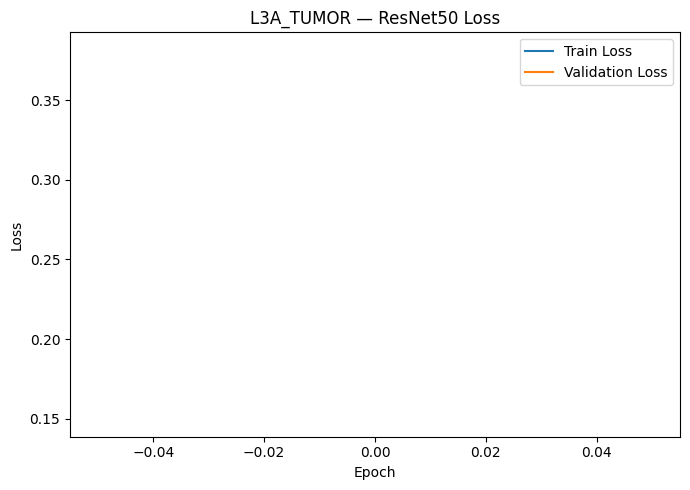

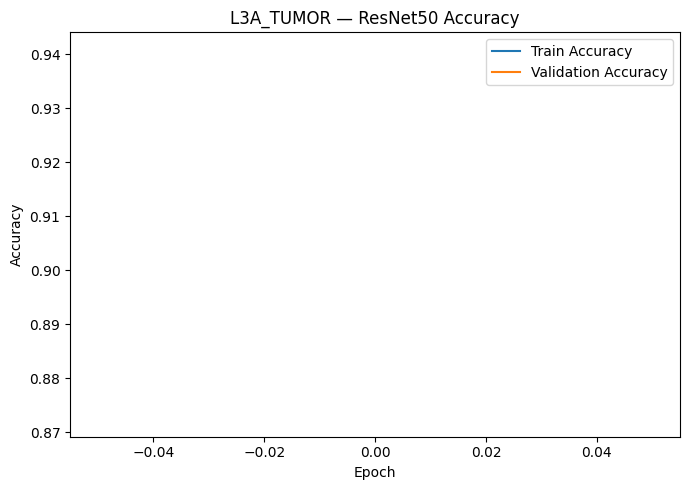

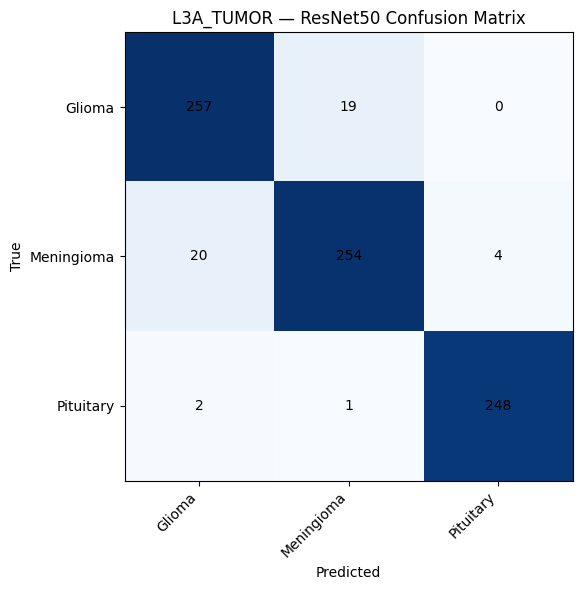

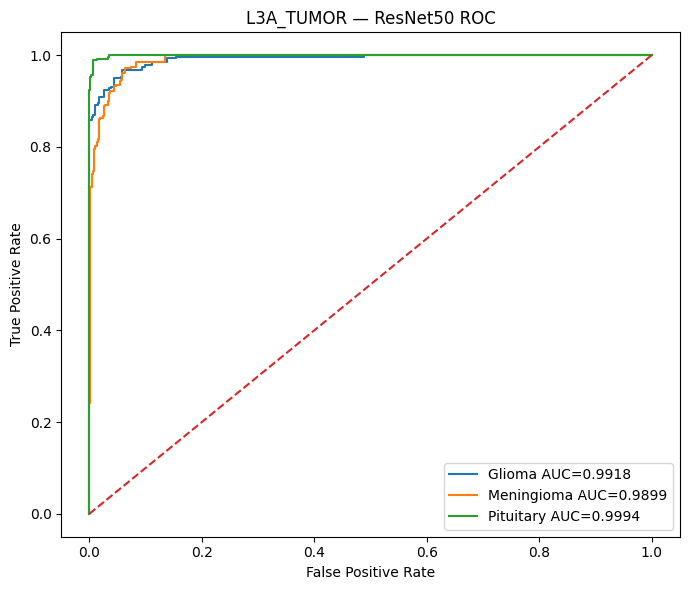


TEST RESULTS
Accuracy: 0.9429
Balanced_Accuracy: 0.9443
F1: 0.9428
ROC_AUC: 0.9935
MCC: 0.9142

MODEL: DenseNet121 | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 161MB/s] 


Epoch 01/1 | Train Loss 0.3051 | Val Loss 0.1364 | Train Acc 0.8829 | Val Acc 0.9493


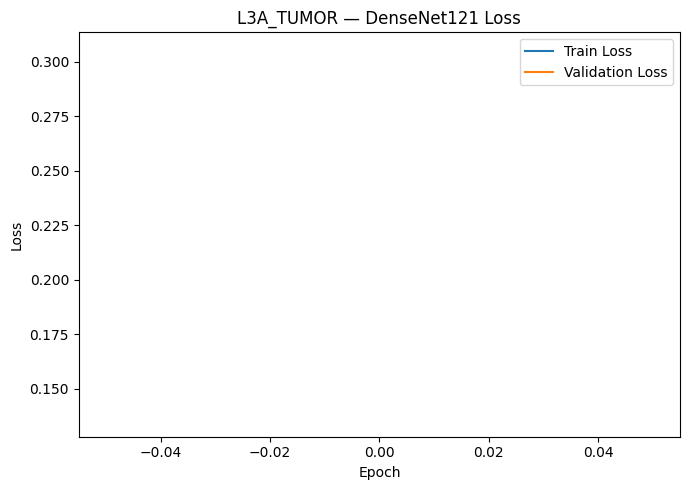

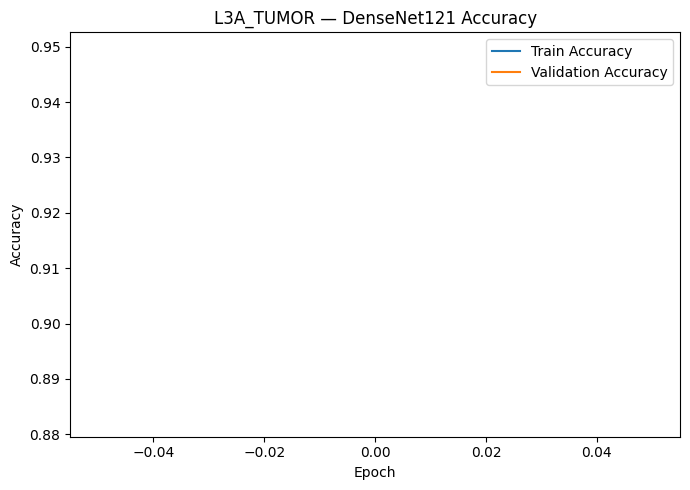

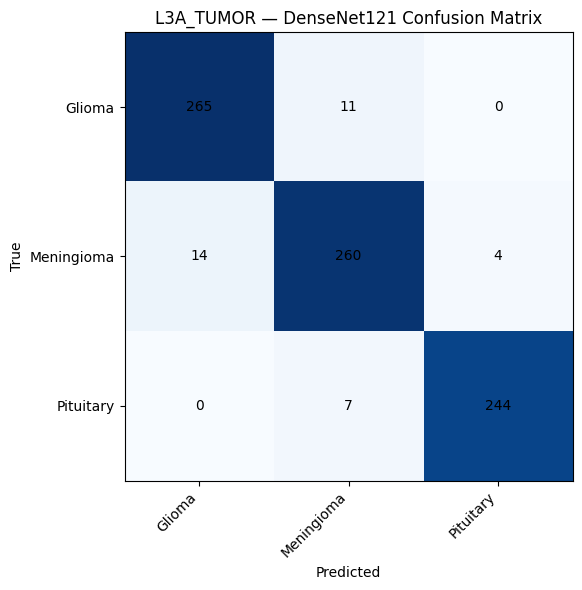

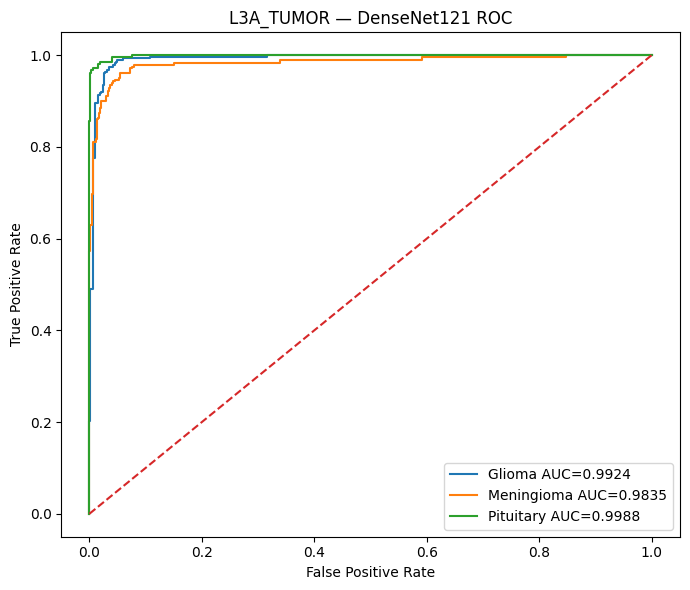


TEST RESULTS
Accuracy: 0.9553
Balanced_Accuracy: 0.9558
F1: 0.9553
ROC_AUC: 0.9913
MCC: 0.9329

MODEL: EfficientNet_B0 | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 


Epoch 01/1 | Train Loss 0.4780 | Val Loss 0.1916 | Train Acc 0.8306 | Val Acc 0.9271


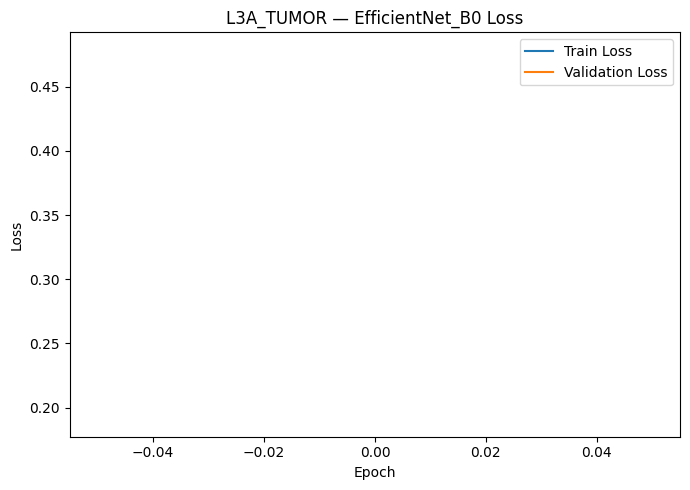

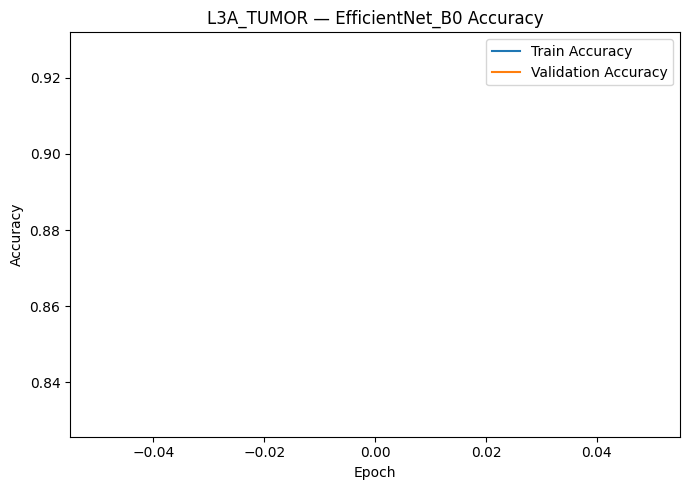

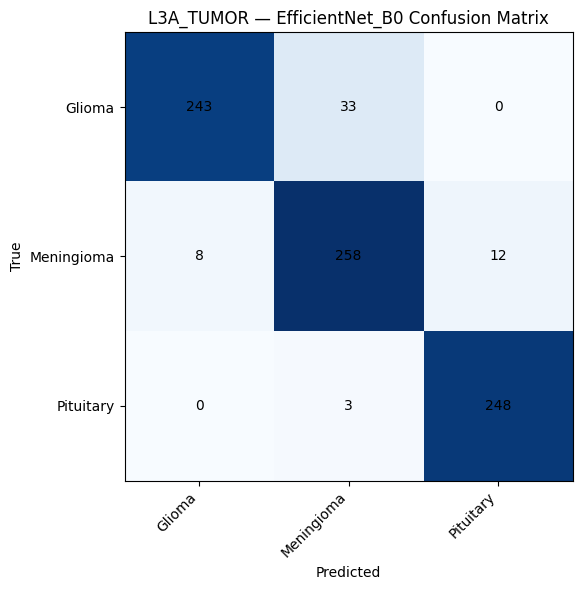

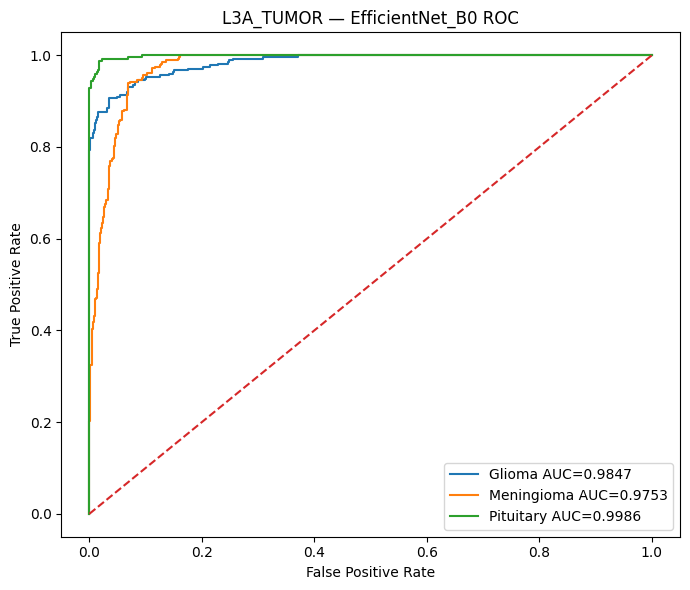


TEST RESULTS
Accuracy: 0.9304
Balanced_Accuracy: 0.9322
F1: 0.9304
ROC_AUC: 0.9858
MCC: 0.8966

MODEL: ConvNeXt_Tiny | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 171MB/s] 


Epoch 01/1 | Train Loss 0.2973 | Val Loss 0.1438 | Train Acc 0.8884 | Val Acc 0.9431


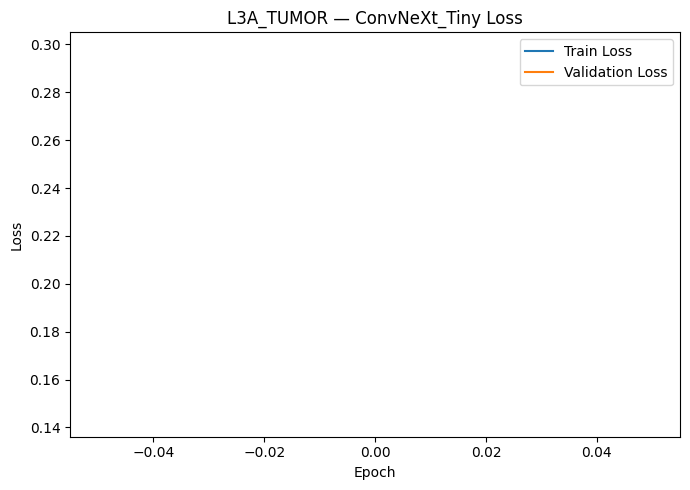

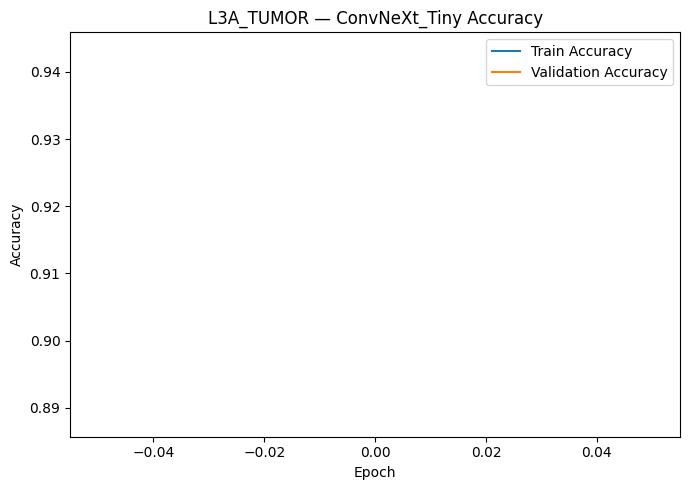

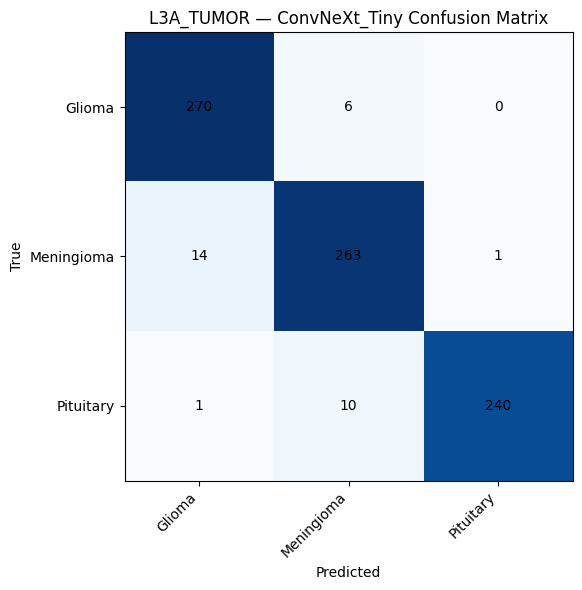

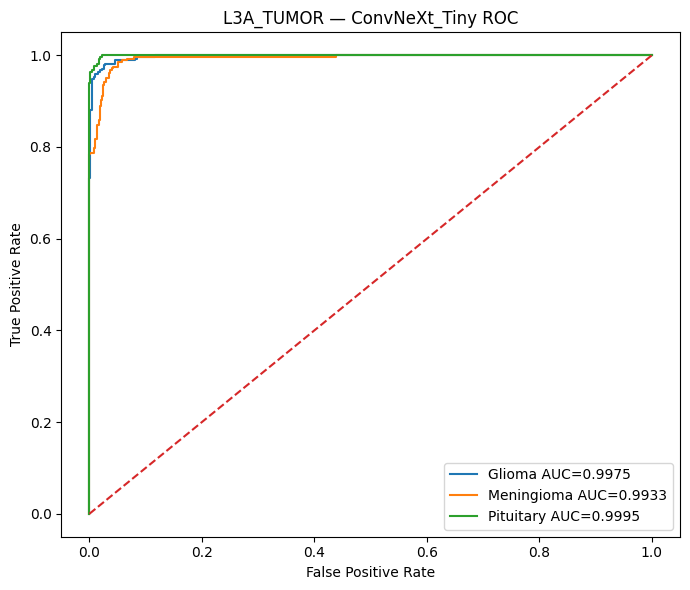


TEST RESULTS
Accuracy: 0.9602
Balanced_Accuracy: 0.9602
F1: 0.9603
ROC_AUC: 0.9967
MCC: 0.9405

MODEL: ViT_B_16 | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 213MB/s]


Epoch 01/1 | Train Loss 0.3465 | Val Loss 0.1205 | Train Acc 0.8617 | Val Acc 0.9592


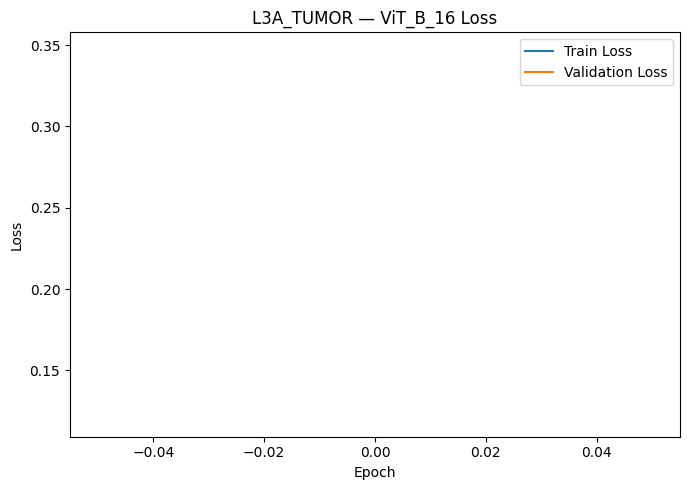

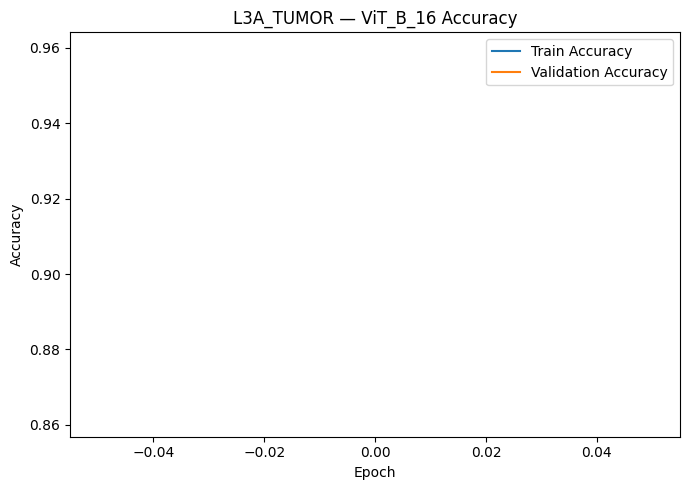

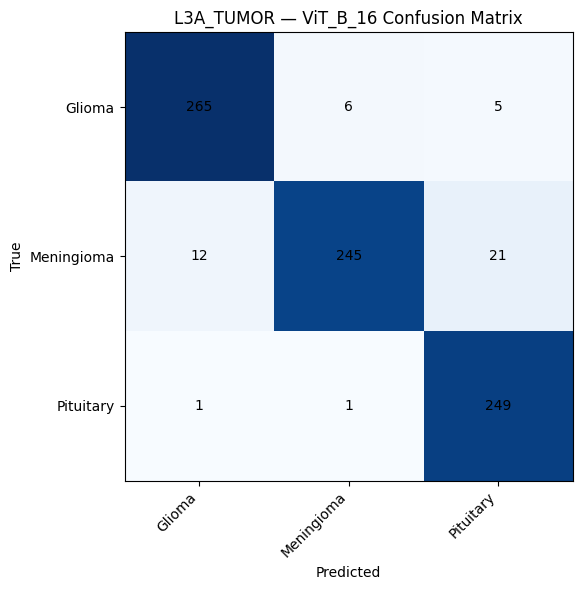

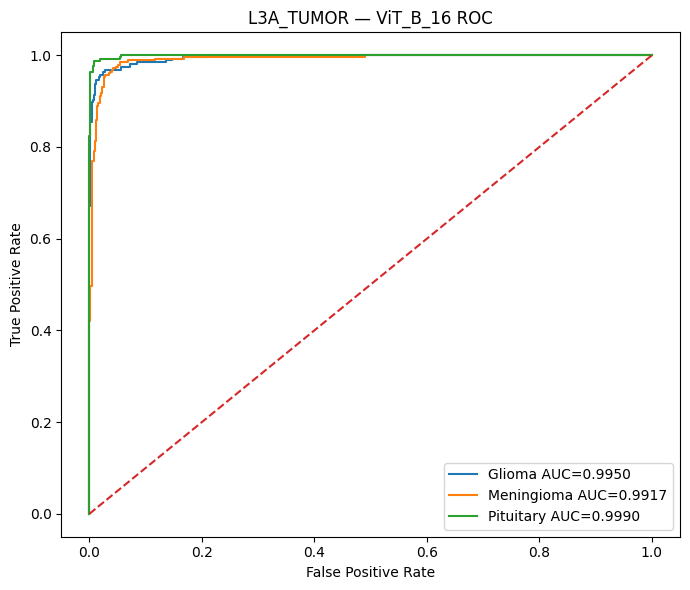


TEST RESULTS
Accuracy: 0.9429
Balanced_Accuracy: 0.9445
F1: 0.9425
ROC_AUC: 0.9951
MCC: 0.9157

MODEL: Swin_T | TASK: L3A_TUMOR
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 217MB/s]


Epoch 01/1 | Train Loss 0.3406 | Val Loss 0.1857 | Train Acc 0.8628 | Val Acc 0.9308


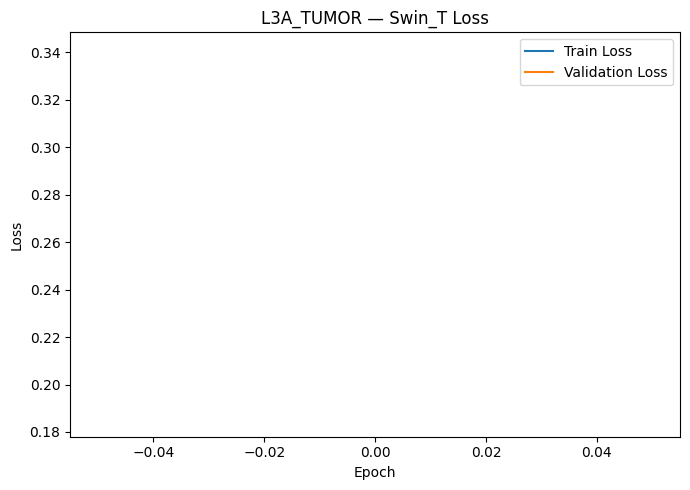

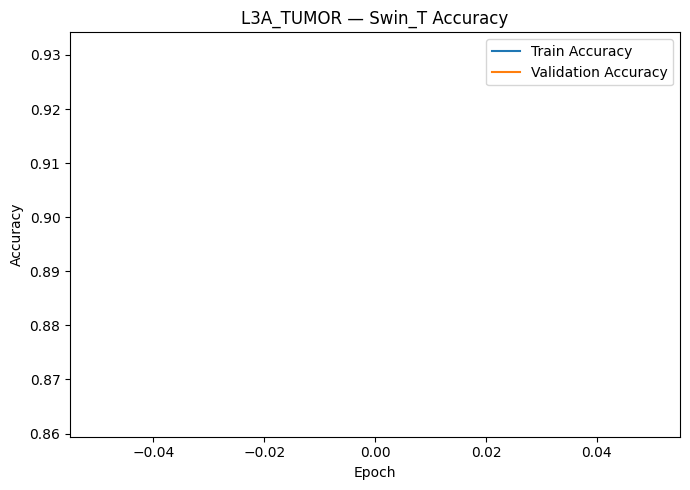

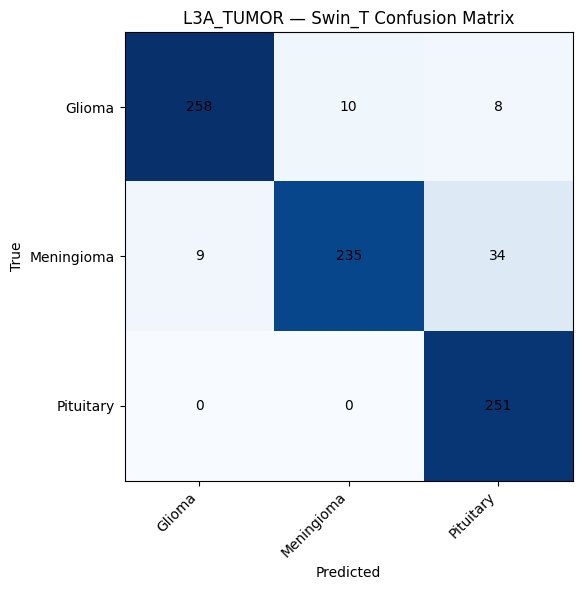

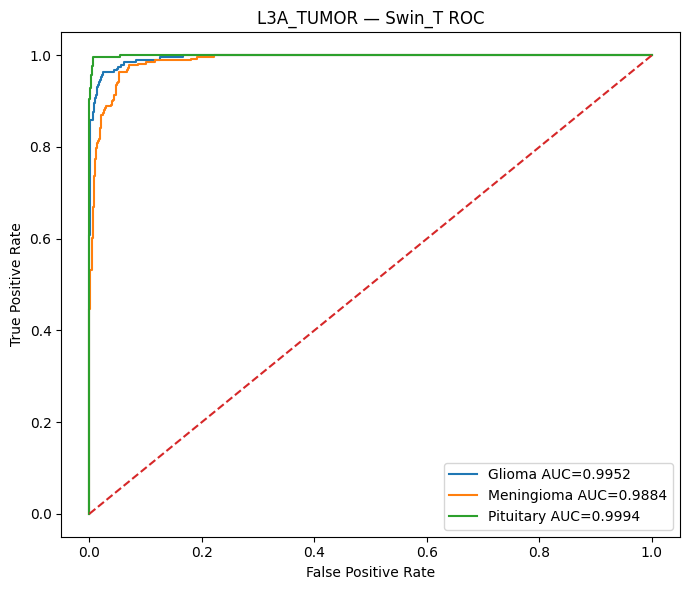


TEST RESULTS
Accuracy: 0.9242
Balanced_Accuracy: 0.9267
F1: 0.9239
ROC_AUC: 0.9942
MCC: 0.8895


,Task,Model,Accuracy,Balanced_Accuracy,F1,ROC_AUC,MCC,Best_Epoch,Training_Time_sec,Inference_Time_sec,Parameters,Trainable_Parameters
0,L3A_TUMOR,ResNet50,0.942857,0.944292,0.942805,0.993515,0.914230,1,47.657830,6.350665,23514179,23514179
1,L3A_TUMOR,DenseNet121,0.955280,0.955836,0.955322,0.991326,0.932857,1,40.646490,3.289166,6956931,6956931
2,L3A_TUMOR,EfficientNet_B0,0.930435,0.932180,0.930364,0.985793,0.896588,1,22.090435,3.221922,4011391,4011391
3,L3A_TUMOR,ConvNeXt_Tiny,0.960248,0.960160,0.960341,0.996662,0.940474,1,103.485433,5.790512,27822435,27822435
4,L3A_TUMOR,ViT_B_16,0.942857,0.944491,0.942486,0.995095,0.915656,1,148.545556,9.540352,85800963,85800963
5,L3A_TUMOR,Swin_T,0.924224,0.926702,0.923883,0.994170,0.889526,1,56.568848,4.113527,27521661,27521661


In [14]:
# Run all baseline models
ALL_RESULTS = []

for model_name in MODEL_NAMES:

    print("\n" + "="*80)
    print("MODEL:", model_name, "| TASK:", TASK)
    print("="*80)

    seed_everything(SEED)

    model = build_model(
        model_name,
        len(CLASSES)
    )

    parameters = sum(
        p.numel() for p in model.parameters()
    )

    trainable_parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    history, checkpoint = train_model(
        model, model_name
    )

    state = torch.load(
        checkpoint,
        map_location=DEVICE
    )

    model.load_state_dict(
        state["model_state_dict"]
    )

    metrics, y_true, y_pred, y_prob, inference_time = evaluate_model(
        model, test_loader
    )

    metrics.update({
        "Task": TASK,
        "Model": model_name,
        "Best_Epoch": history["best_epoch"],
        "Training_Time_sec": history["training_time_sec"],
        "Inference_Time_sec": inference_time,
        "Parameters": parameters,
        "Trainable_Parameters": trainable_parameters
    })

    ALL_RESULTS.append(metrics)

    # JSON metrics
    with open(
        RESULT_DIR / f"{TASK}_{model_name}_metrics.json",
        "w"
    ) as f:
        json.dump(
            {
                k: (
                    float(v)
                    if isinstance(v, (np.floating, np.integer))
                    else v
                )
                for k,v in metrics.items()
            },
            f,
            indent=2
        )

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0
    )

    with open(
        RESULT_DIR / f"{TASK}_{model_name}_classification_report.json",
        "w"
    ) as f:
        json.dump(report, f, indent=2)

    save_outputs(
        history,
        model_name,
        y_true,
        y_pred,
        y_prob
    )

    print("\nTEST RESULTS")
    for key in [
        "Accuracy",
        "Balanced_Accuracy",
        "F1",
        "ROC_AUC",
        "MCC"
    ]:
        print(f"{key}: {metrics[key]:.4f}")

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(ALL_RESULTS)

columns = [
    "Task",
    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "ROC_AUC",
    "MCC",
    "Best_Epoch",
    "Training_Time_sec",
    "Inference_Time_sec",
    "Parameters",
    "Trainable_Parameters"
]

results_df = results_df[
    [c for c in columns if c in results_df.columns]
]

results_df.to_csv(
    RESULT_DIR / f"{TASK}_baseline_comparison.csv",
    index=False
)

display(results_df)


In [15]:
# Class distribution + output inventory
distribution = pd.DataFrame({
    "Train": task_train[LABEL_COL].value_counts(),
    "Validation": task_val[LABEL_COL].value_counts(),
    "Test": task_test[LABEL_COL].value_counts()
}).fillna(0).astype(int).reindex(CLASSES)

distribution.to_csv(
    RESULT_DIR / f"{TASK}_class_distribution.csv"
)

display(distribution)

print("\nExperiment 2 output files:")
for p in OUTPUT_ROOT.rglob("*"):
    if p.is_file():
        print(p.relative_to(OUTPUT_ROOT))


,Train,Validation,Test
l3a_name,,,
Glioma,1235,288,276
Meningioma,1269,251,278
Pituitary,1279,270,251



Experiment 2 output files:
results/L3A_TUMOR_EfficientNet_B0_classification_report.json
results/L3A_TUMOR_ViT_B_16_metrics.json
results/L3A_TUMOR_DenseNet121_metrics.json
results/L3A_TUMOR_Swin_T_classification_report.json
results/L3A_TUMOR_class_distribution.csv
results/L3A_TUMOR_Swin_T_metrics.json
results/L3A_TUMOR_baseline_comparison.csv
results/L3A_TUMOR_ConvNeXt_Tiny_metrics.json
results/L3A_TUMOR_ConvNeXt_Tiny_classification_report.json
results/L3A_TUMOR_ResNet50_classification_report.json
results/L3A_TUMOR_ResNet50_metrics.json
results/L3A_TUMOR_DenseNet121_classification_report.json
results/L3A_TUMOR_EfficientNet_B0_metrics.json
results/L3A_TUMOR_ViT_B_16_classification_report.json
checkpoints/L3A_TUMOR_Swin_T_best.pth
checkpoints/L3A_TUMOR_ViT_B_16_best.pth
checkpoints/L3A_TUMOR_DenseNet121_best.pth
checkpoints/L3A_TUMOR_EfficientNet_B0_best.pth
checkpoints/L3A_TUMOR_ConvNeXt_Tiny_best.pth
checkpoints/L3A_TUMOR_ResNet50_best.pth
plots/L3A_TUMOR_DenseNet121_loss.png
plots/L3A

## Run all hierarchy levels

Change `TASK` in the task-selection cell and run the notebook for:

- `L1`
- `L2`
- `L3A_TUMOR`
- `L3B_ALZHEIMER`
- `L3C_STROKE`

Model selection uses validation loss. The test set is used only for final evaluation.

The notebook retains the Experiment-1 split and does not claim a patient-level split because genuine patient/study identifiers were unavailable.


In [16]:
import os
import zipfile
from IPython.display import FileLink

zip_path = '/kaggle/working/all_files.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk('/kaggle/working'):
        for file in files:
            if file == 'all_files.zip':
                continue

            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, '/kaggle/working')

            zipf.write(full_path, arcname)

print("ZIP তৈরি হয়েছে:", zip_path)
display(FileLink(zip_path))

ZIP তৈরি হয়েছে: /kaggle/working/all_files.zip


/kaggle/working/all_files.zip